# Notebook 07: Instruction Fine-Tuning

## Transforming a Base Model into a Q&A System

In notebook 06, we trained a **base language model** on Shakespeare's works. This model can:
- Generate text in Shakespeare's style
- Complete sentences authentically
- Predict the next token given context

But what it **cannot** do is:
- Answer questions like "What is Hamlet about?"
- Follow instructions like "Summarize Act 1"
- Respond appropriately to prompts

In this notebook, we'll transform our base model into an **instruction-following model** through **instruction fine-tuning**.

## The Three-Stage LLM Pipeline

Modern large language models like GPT-4, Claude, and Llama are trained in three stages:

```
Stage 1: Pre-training (Notebook 06)
  ? Train on massive text corpus
  ? Learn language patterns, grammar, facts
  ? Objective: Predict next token

Stage 2: Supervised Fine-Tuning (This Notebook)
  ? Train on (instruction, response) pairs
  ? Learn to follow instructions
  ? Objective: Generate appropriate responses

Stage 3: RLHF (Not covered)
  ? Train with human feedback
  ? Align with human preferences
  ? Objective: Maximize helpfulness/harmlessness
```

Today we'll implement **Stage 2: Supervised Fine-Tuning (SFT)**.

## What You'll Learn

1. How to create an instruction-following dataset
2. The importance of loss masking (only train on answers, not questions)
3. How fine-tuning differs from pre-training
4. Evaluating instruction-following capabilities

Let's get started!

## Section 1: Setup and Imports

In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import numpy as np
import matplotlib.pyplot as plt
import json
import re
from collections import Counter
from tqdm import tqdm
import random
import math

# Set random seeds for reproducibility
torch.manual_seed(42)
np.random.seed(42)
random.seed(42)

# Device configuration
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

Using device: cuda


## Section 2: Load Pre-trained Model from Notebook 06

First, we need to reconstruct our model architecture and tokenizer from notebook 06.

In [2]:
# Import shared model components from src
import os
import sys

sys.path.append(os.path.abspath('../src'))
from model import (
    PositionalEncoding,
    FeedForward,
    CausalMultiHeadAttention,
    GPTBlock,
    MiniGPT,
)

print('Model components imported from src/model.py')


Model components imported from src/model.py


In [3]:
from tokenizer import CharacterTokenizer, BPETokenizer, build_tokenizer, tokenizer_from_checkpoint

print('Tokenizer helpers imported from src/tokenizer.py')


Tokenizer helpers imported from src/tokenizer.py


### Initialize Tokenizer and Train on Shakespeare Text

In [4]:
# Load Shakespeare text
with open('../data/shakespeare.txt', 'r', encoding='utf-8') as f:
    shakespeare_text = f.read()

print(f'Loaded {len(shakespeare_text):,} characters of Shakespeare text')

# Default tokenizer setup before checkpoint restore.
# This keeps the notebook runnable even if no checkpoint is available yet.
tokenizer_type = 'bpe'  # 'char' or 'bpe'
tokenizer_lowercase = False
tokenizer_vocab_size = 2000 if tokenizer_type == 'bpe' else 5000

tokenizer = build_tokenizer(
    tokenizer_type=tokenizer_type,
    vocab_size=tokenizer_vocab_size,
    lowercase=tokenizer_lowercase,
)
tokenizer.train(shakespeare_text)

print(f'Default tokenizer type: {tokenizer.tokenizer_type}')
if tokenizer.tokenizer_type == 'bpe':
    print(f'Default lowercase mode: {tokenizer.lowercase}')
print(f'Tokenizer vocabulary size: {len(tokenizer)}')


Loaded 1,115,394 characters of Shakespeare text
Default tokenizer type: bpe
Default lowercase mode: False
Tokenizer vocabulary size: 2000


### Load Pre-trained Model

We load the pre-trained model checkpoint from notebook 06. This model has already learned the basic patterns of Shakespeare's writing style.

In [5]:
# Load the Shakespeare Wikipedia pre-trained model from notebook 06
checkpoint_name = 'shakespeare_wikipedia_pretrained_bpe_paper_inspired_small.pt'
checkpoint_path = f'../models/{checkpoint_name}'

try:
    checkpoint = torch.load(checkpoint_path, map_location=device)

    # Restore tokenizer from checkpoint metadata when available.
    tokenizer = tokenizer_from_checkpoint(checkpoint, default_vocab_size=tokenizer_vocab_size)

    # Rebuild model with saved config
    config = checkpoint['config']
    model = MiniGPT(**config).to(device)
    model.load_state_dict(checkpoint['model_state_dict'])

    print(f'Loaded pre-trained model from {checkpoint_path}')
    print(f"  Corpus choice: {checkpoint.get('corpus_choice', 'unknown')}")
    print(f"  Model preset:  {checkpoint.get('model_preset', 'unknown')}")
    print(f'  Tokenizer type: {tokenizer.tokenizer_type}')
    print(f"  Vocab size:  {config['vocab_size']}")
    print(f"  d_model:     {config['d_model']}")
    print(f"  num_layers:  {config['num_layers']}")
    print(f"  num_heads:   {config['num_heads']}")
    print(f"  d_ff:        {config['d_ff']}")
    print(f"  max_seq_len: {config['max_seq_len']}")
    print(f"  activation:  {config.get('activation', 'relu')}")
    print(f"  position_encoding_type: {config.get('position_encoding_type', 'sinusoidal')}")
    print(f'  Parameters: {sum(p.numel() for p in model.parameters()):,}')

    # --- Layer Freezing for Fine-tuning ---
    # Freeze embeddings + lower 6 blocks. Only top 2 blocks + ln_final + output_projection
    # remain trainable (~4M params vs 15.8M total), preventing overfitting on the small Q&A dataset.
    freeze_layers = [model.token_embedding, model.pos_encoding] + list(model.blocks[:6])
    for layer in freeze_layers:
        for param in layer.parameters():
            param.requires_grad = False

    total_params = sum(p.numel() for p in model.parameters())
    trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
    frozen_params = total_params - trainable_params
    print('\n--- Layer Freezing ---')
    print('  Frozen:    token_embedding, pos_encoding, blocks 0-5')
    print('  Trainable: blocks 6-7, ln_final, output_projection')
    print(f'  Total params:     {total_params:>12,}')
    print(f'  Frozen params:    {frozen_params:>12,} ({frozen_params / total_params * 100:.1f}%)')
    print(f'  Trainable params: {trainable_params:>12,} ({trainable_params / total_params * 100:.1f}%)')

except FileNotFoundError:
    print('ERROR: Pre-trained model not found!')
    print('Please run notebook 06 first to create the pre-trained checkpoint.')
    raise


Loaded pre-trained model from ../models/shakespeare_wikipedia_pretrained_bpe_paper_inspired_small.pt
  Corpus choice: shakespeare_wikipedia
  Model preset:  paper_inspired_small
  Tokenizer type: bpe
  Vocab size:  2000
  d_model:     384
  num_layers:  8
  num_heads:   8
  d_ff:        1536
  max_seq_len: 256
  activation:  gelu
  position_encoding_type: learned
  Parameters: 15,832,784

--- Layer Freezing ---
  Frozen:    token_embedding, pos_encoding, blocks 0-5
  Trainable: blocks 6-7, ln_final, output_projection
  Total params:       15,832,784
  Frozen params:      11,513,088 (72.7%)
  Trainable params:    4,319,696 (27.3%)


### Test Generation Before Fine-Tuning

In [6]:
from inference import generate_sample

# Test with a question (should fail)
print('\n=== BEFORE FINE-TUNING ===')
print("\nPrompt: 'Question: What is Hamlet about?\nAnswer:'")
print('Expected: A coherent answer about Hamlet')
print('\nActual output:')
output = generate_sample(
    model,
    tokenizer,
    'Question: What is Hamlet about?\nAnswer:',
    max_len=50,
    device=device,
    max_seq_len=config['max_seq_len'],
)
print(output)
print('\n(The model will likely just continue with Shakespeare-style text, not answer the question)')



=== BEFORE FINE-TUNING ===

Prompt: 'Question: What is Hamlet about?
Answer:'
Expected: A coherent answer about Hamlet

Actual output:
Question: What is Hamlet about? Answer: " Where You will not win this o ' d, / I continue you ' re it as will know? ' d no insay " ( ll. 29 – 222 ). Also, after she says

(The model will likely just continue with Shakespeare-style text, not answer the question)


## Section 3: Creating the Q&A Dataset

Since no pre-existing Shakespeare Q&A dataset exists, we'll create one programmatically using:
1. **Template-based generation** for common questions
2. **Text parsing** to extract characters, quotes, and facts

This approach generates ~500-1000 Q&A pairs covering:
- Character questions
- Quote identification and completion
- Plot summaries
- Themes and analysis

In [7]:
# Extract character names from the text
def extract_characters(text, min_occurrences=5):
    """Extract character names that appear as speakers."""
    # Pattern: Character name followed by colon at line start
    pattern = r'^([A-Z][A-Za-z\s]+):\s*$'
    
    characters = []
    for line in text.split('\n'):
        match = re.match(pattern, line.strip())
        if match:
            char_name = match.group(1).strip()
            # Filter out generic names
            if len(char_name) > 2 and char_name not in ['All', 'Both', 'Others']:
                characters.append(char_name)
    
    # Count occurrences
    char_counts = Counter(characters)
    
    # Return characters that appear frequently enough
    return [char for char, count in char_counts.items() if count >= min_occurrences]

characters = extract_characters(shakespeare_text)
print(f"Found {len(characters)} major characters")
print(f"Sample characters: {characters[:10]}")

Found 183 major characters
Sample characters: ['First Citizen', 'Second Citizen', 'MENENIUS', 'MARCIUS', 'Messenger', 'First Senator', 'COMINIUS', 'SICINIUS', 'BRUTUS', 'AUFIDIUS']


In [8]:
# Extract memorable quotes (longer lines)
def extract_quotes(text, min_length=40, max_length=150):
    """Extract notable quotes from the text."""
    quotes = []
    lines = text.split('\n')
    
    current_speaker = None
    
    for line in lines:
        line = line.strip()
        
        # Check if it's a speaker line
        if line and line[0].isupper() and ':' in line and not line.startswith(' '):
            parts = line.split(':', 1)
            if len(parts[0]) < 30:  # Reasonable speaker name length
                current_speaker = parts[0].strip()
                line = parts[1].strip() if len(parts) > 1 else ''
        
        # Extract quote if it's substantial
        if line and min_length <= len(line) <= max_length and current_speaker:
            # Clean up
            if not any(x in line.lower() for x in ['exit', 'enter', 'exeunt']):
                quotes.append((current_speaker, line))
    
    return quotes[:200]  # Limit to 200 quotes

quotes = extract_quotes(shakespeare_text)
print(f"\nExtracted {len(quotes)} quotes")
print(f"\nSample quote:")
if quotes:
    speaker, quote = quotes[0]
    print(f"{speaker}: {quote}")


Extracted 200 quotes

Sample quote:
First Citizen: Before we proceed any further, hear me speak.


In [10]:
import random

# Load the Hamlet-focused SFT dataset and split in-memory
hamlet_path = '../data/hamlet_qa_expanded.json'
with open(hamlet_path, 'r', encoding='utf-8') as f:
    all_hamlet_qa = json.load(f)

random.seed(42)
random.shuffle(all_hamlet_qa)
split = int(0.9 * len(all_hamlet_qa))
train_qa = all_hamlet_qa[:split]
val_qa   = all_hamlet_qa[split:]

print(f'Loaded Hamlet-focused SFT dataset')
print(f'  Training pairs:   {len(train_qa)}')
print(f'  Validation pairs: {len(val_qa)}')
print(f'  Total:            {len(all_hamlet_qa)}')

print('Sample Q&A pairs:')
for question, answer in train_qa[:5]:
    print(f'  Q: {question}')
    print(f'  A: {answer}')
    print()


Loaded Hamlet-focused SFT dataset
  Training pairs:   433
  Validation pairs: 49
  Total:            482
Sample Q&A pairs:
  Q: What is the ending of Hamlet like?
  A: The ending is tragic and filled with death, revenge, and political collapse.

  Q: Why does Gertrude marry Claudius?
  A: Gertrude marries Claudius possibly for political security and stability, but her true motives remain deliberately ambiguous in the play.

  Q: What is Claudius's importance in the play?
  A: Claudius is important because his crime drives the tragedy.

  Q: How is Gertrude's character related to Hamlet in Hamlet?
  A: Gertrude is Hamlet's mother.

  Q: What are Hamlet's thoughts on revenge in Hamlet?
  A: Hamlet sees revenge as necessary, but he is troubled by its moral consequences.



In [11]:
# Hamlet-focused SFT dataset summary
print('SFT Dataset: Hamlet-Focused')
print('  Source: ../data/hamlet_qa_expanded.json')
print('  Split: 90% train / 10% val (seed 42, in-memory)')
print('  Generated by: scripts/generate_hamlet_qa.py + scripts/merge_hamlet_qa.py')


SFT Dataset: Hamlet-Focused
  Source: ../data/hamlet_qa_expanded.json
  Split: 90% train / 10% val (seed 42, in-memory)
  Generated by: scripts/generate_hamlet_qa.py + scripts/merge_hamlet_qa.py


## Section 4: The Instruction Dataset Class

The key innovation in instruction fine-tuning is **loss masking**:

```
Pre-training:     Train on ALL tokens
Fine-tuning:      Train ONLY on answer tokens
```

### Why Mask the Question?

1. **Questions are input**: We don't want to modify how the model processes questions
2. **Answers are output**: We only want to teach the model to generate good answers
3. **Efficiency**: Focus learning signal on what matters

### Format

```
Input:  "Question: What is Hamlet about?\nAnswer: Hamlet is a tragedy..."
        +---------------------------+ +--------------------+
               Loss mask = 0              Loss mask = 1
```

In [12]:
class InstructionDataset(Dataset):
    """Dataset for Hamlet-focused instruction fine-tuning with Q&A pairs."""
    
    def __init__(self, qa_pairs, tokenizer, max_len=256):
        self.qa_pairs = qa_pairs
        self.tokenizer = tokenizer
        self.max_len = max_len
        self.eos_token = tokenizer.get_endoftext_token()
        self.pad_token = tokenizer.get_pad_token()
        self.instruction = '[HAMLET_QA]\nInstruction: Answer the question in one short factual sentence.'
        
    def __len__(self):
        return len(self.qa_pairs)
    
    def __getitem__(self, idx):
        question, answer = self.qa_pairs[idx]
        prompt = f"{self.instruction}\nQuestion: {question}\nAnswer:"
        completion = f" {answer}"
        
        prompt_tokens = self.tokenizer.encode(prompt)
        completion_tokens = self.tokenizer.encode(completion)
        completion_tokens.append(self.eos_token)
        
        full_tokens = prompt_tokens + completion_tokens
        if len(full_tokens) > self.max_len:
            full_tokens = full_tokens[:self.max_len]
            if len(prompt_tokens) >= self.max_len:
                prompt_tokens = prompt_tokens[:self.max_len - 10]
        
        input_ids = full_tokens[:-1]
        target_ids = full_tokens[1:]
        prompt_len = len(prompt_tokens) - 1
        loss_mask = [0] * prompt_len + [1] * (len(input_ids) - prompt_len)
        
        padding_len = self.max_len - len(input_ids) - 1
        if padding_len > 0:
            input_ids = input_ids + [self.pad_token] * padding_len
            target_ids = target_ids + [self.pad_token] * padding_len
            loss_mask = loss_mask + [0] * padding_len
        
        return {
            'input_ids': torch.tensor(input_ids, dtype=torch.long),
            'target_ids': torch.tensor(target_ids, dtype=torch.long),
            'loss_mask': torch.tensor(loss_mask, dtype=torch.float)
        }

print('InstructionDataset class defined')


InstructionDataset class defined


### Visualize the Loss Mask

In [13]:
# Create dataset from the Hamlet training split preview
instruction_dataset = InstructionDataset(train_qa, tokenizer, max_len=128)

sample = instruction_dataset[0]
input_ids = sample['input_ids']
loss_mask = sample['loss_mask']

print('Sample from InstructionDataset:')
print(f"\nInput shape: {input_ids.shape}")
print(f"Loss mask shape: {loss_mask.shape}")
print(f"Dataset source size: {len(train_qa)} Hamlet training pairs")

print('\nDecoded sequence with loss mask:')
print('-' * 80)

decoded = tokenizer.decode(input_ids.tolist())
print(f'Full text: {decoded}')
print(f"\nLoss mask (first 50 positions):")
print(loss_mask[:50].tolist())
print('\n0 = Question (no loss), 1 = Answer (compute loss)')


Sample from InstructionDataset:

Input shape: torch.Size([127])
Loss mask shape: torch.Size([127])
Dataset source size: 433 Hamlet training pairs

Decoded sequence with loss mask:
--------------------------------------------------------------------------------
Full text: [ HAMLET<UNK>QA ] Instruction: Answer the question in one short factual sentence. Question: What is the ending of Hamlet like? Answer: The ending is tragic and filled with death, revenge, and political collapse.

Loss mask (first 50 positions):
[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 1.0]

0 = Question (no loss), 1 = Answer (compute loss)


## Section 5: Masked Loss Function

Standard cross-entropy loss computes:
```
loss = mean(CrossEntropy(logits, targets))
```

Masked loss computes:
```
loss = sum(CrossEntropy(logits, targets) * mask) / sum(mask)
```

This ensures we only train on answer tokens.

In [14]:
def compute_instruction_loss(logits, targets, loss_mask):
    """
    Compute loss only on answer tokens (not question tokens).
    
    Args:
        logits: (batch, seq_len, vocab_size) - Model predictions
        targets: (batch, seq_len) - Ground truth token IDs
        loss_mask: (batch, seq_len) - 1 for answer tokens, 0 for question tokens
    
    Returns:
        Scalar loss value
    """
    batch_size, seq_len, vocab_size = logits.shape
    
    # Reshape for cross entropy
    logits_flat = logits.view(batch_size * seq_len, vocab_size)
    targets_flat = targets.view(batch_size * seq_len)
    loss_mask_flat = loss_mask.view(batch_size * seq_len)
    
    # Compute per-token loss
    loss_per_token = F.cross_entropy(logits_flat, targets_flat, reduction='none')
    
    # Apply mask and average only over answer tokens
    masked_loss = loss_per_token * loss_mask_flat
    
    # Average over non-masked tokens
    total_loss = masked_loss.sum()
    num_tokens = loss_mask_flat.sum()
    
    # Avoid division by zero
    if num_tokens > 0:
        avg_loss = total_loss / num_tokens
    else:
        avg_loss = total_loss
    
    return avg_loss

print("Masked loss function defined")

Masked loss function defined


## Section 6: Fine-Tuning Setup

### Key Differences from Pre-Training

| Aspect | Pre-Training | Fine-Tuning |
|--------|--------------|-------------|
| **Learning Rate** | 3e-4 (high) | 1e-5 (low) |
| **Epochs** | 10-50 | 1-3 |
| **Data** | Raw text | Q&A pairs |
| **Loss** | All tokens | Answer tokens only |
| **Goal** | Learn language | Learn to follow instructions |

In [15]:
# Use the Hamlet-only Q&A split for focused fine-tuning
print('Loaded Hamlet-focused fine-tuning datasets from data/')
print(f'  Training pairs: {len(train_qa)}')
print(f'  Validation pairs: {len(val_qa)}')

train_dataset = InstructionDataset(train_qa, tokenizer, max_len=128)
val_dataset = InstructionDataset(val_qa, tokenizer, max_len=128)

train_loader = DataLoader(train_dataset, batch_size=8, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=8, shuffle=False)

print(f'\nDatasets created!')
print(f'  Training examples:   {len(train_dataset)}')
print(f'  Validation examples: {len(val_dataset)}')
print(f'  Training batches:    {len(train_loader)}')
print(f'  Validation batches:  {len(val_loader)}')


Loaded Hamlet-focused fine-tuning datasets from data/
  Training pairs: 433
  Validation pairs: 49

Datasets created!
  Training examples:   433
  Validation examples: 49
  Training batches:    55
  Validation batches:  7


In [16]:
# Fine-tuning hyperparameters (with layer freezing)
learning_rate = 5e-5     # Lower LR: smaller Hamlet dataset (~434 pairs) overfits faster than the 857-pair all-plays set
num_epochs = 80          # Early stopping will cut this short
eval_temperature = 0.7   # 0.7 avoids greedy-decoding repetition loops (was 0.2)
eval_max_len = 50
warmup_steps = 30        # Fewer params warm up faster
patience = 15            # Stop after 15 epochs with no val loss improvement

# IMPORTANT: Only pass trainable (unfrozen) parameters to the optimizer.
# Passing frozen params wastes memory on optimizer state and is misleading.
optimizer = torch.optim.AdamW(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=learning_rate,
    weight_decay=0.01,
)

# Learning rate scheduler
def get_lr(step, warmup_steps, max_steps):
    if step < warmup_steps:
        return step / warmup_steps
    else:
        progress = (step - warmup_steps) / (max_steps - warmup_steps)
        return 0.5 * (1 + np.cos(np.pi * progress))

print(f'Optimizer configured with LR={learning_rate}')
print(f'Max epochs: {num_epochs} (early stopping patience={patience})')
print(f'Evaluation temperature: {eval_temperature}')
print(f'Evaluation max_len: {eval_max_len}')


Optimizer configured with LR=5e-05
Max epochs: 80 (early stopping patience=15)
Evaluation temperature: 0.7
Evaluation max_len: 50


## Section 7: Training Loop

In [17]:
def train_epoch(model, train_loader, optimizer, device, step):
    """Train for one epoch."""
    model.train()
    total_loss = 0
    num_batches = len(train_loader)
    
    progress_bar = tqdm(train_loader, desc="Training")
    
    for batch in progress_bar:
        input_ids = batch['input_ids'].to(device)
        target_ids = batch['target_ids'].to(device)
        loss_mask = batch['loss_mask'].to(device)
        
        # Forward pass
        logits = model(input_ids)
        
        # Compute masked loss
        loss = compute_instruction_loss(logits, target_ids, loss_mask)
        
        # Backward pass
        optimizer.zero_grad()
        loss.backward()
        
        # Gradient clipping
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        
        optimizer.step()
        
        # Update learning rate
        step += 1
        lr_mult = get_lr(step, warmup_steps, num_epochs * num_batches)
        for param_group in optimizer.param_groups:
            param_group['lr'] = learning_rate * lr_mult
        
        total_loss += loss.item()
        progress_bar.set_postfix({'loss': loss.item()})
    
    return total_loss / num_batches, step


def validate(model, val_loader, device):
    """Validate the model."""
    model.eval()
    total_loss = 0
    
    with torch.no_grad():
        for batch in val_loader:
            input_ids = batch['input_ids'].to(device)
            target_ids = batch['target_ids'].to(device)
            loss_mask = batch['loss_mask'].to(device)
            
            logits = model(input_ids)
            loss = compute_instruction_loss(logits, target_ids, loss_mask)
            
            total_loss += loss.item()
    
    return total_loss / len(val_loader)

print("Training functions defined")

Training functions defined


In [18]:
import copy

# Training loop with best-checkpoint saving and early stopping
train_losses = []
val_losses = []
step = 0

best_val_loss = float('inf')
best_model_state = None
epochs_without_improvement = 0

print('Starting fine-tuning...\n')

for epoch in range(num_epochs):
    print(f'\nEpoch {epoch + 1}/{num_epochs}')
    print('-' * 50)

    # Train
    train_loss, step = train_epoch(model, train_loader, optimizer, device, step)
    train_losses.append(train_loss)

    # Validate
    val_loss = validate(model, val_loader, device)
    val_losses.append(val_loss)

    print(f'Train Loss: {train_loss:.4f}')
    print(f'Val Loss:   {val_loss:.4f}')

    # Save best checkpoint
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_model_state = copy.deepcopy(model.state_dict())
        epochs_without_improvement = 0
        print(f'  >> New best val loss: {best_val_loss:.4f} -- checkpoint saved')
    else:
        epochs_without_improvement += 1
        print(f'  No improvement for {epochs_without_improvement}/{patience} epochs')

    # Early stopping
    if epochs_without_improvement >= patience:
        print(f'\nEarly stopping triggered after {epoch + 1} epochs.')
        break

    # Sample generation every 5 epochs
    if (epoch + 1) % 5 == 0 or epoch == 0:
        print('\nSample generation:')
        test_q = 'Question: Who is Hamlet?\nAnswer:'
        output = generate_sample(
            model, tokenizer, test_q,
            max_len=20, temperature=eval_temperature,
            device=device, max_seq_len=config['max_seq_len'],
        )
        print(output)

# Restore best model before evaluation
if best_model_state is not None:
    model.load_state_dict(best_model_state)
    print(f'\nRestored best model (val loss: {best_val_loss:.4f})')

# Save best checkpoint to disk
save_path = '../models/hamlet_finetuned_best.pt'
torch.save({
    'model_state_dict': best_model_state,
    'config': config,
    'best_val_loss': best_val_loss,
}, save_path)
print(f'Best checkpoint saved to {save_path}')
print('\nFine-tuning complete!')


Starting fine-tuning...


Epoch 1/80
--------------------------------------------------


Training: 100%|██████████| 55/55 [00:14<00:00,  3.86it/s, loss=4.72]


Train Loss: 4.4229
Val Loss:   3.6310
  >> New best val loss: 3.6310 -- checkpoint saved

Sample generation:
Question: Who is Hamlet? Answer: Cleopatra, she is further, she is deserves, and the nery, she is

Epoch 2/80
--------------------------------------------------


Training: 100%|██████████| 55/55 [00:14<00:00,  3.83it/s, loss=4.06]


Train Loss: 3.5879
Val Loss:   3.3096
  >> New best val loss: 3.3096 -- checkpoint saved

Epoch 3/80
--------------------------------------------------


...

Train Loss: 1.3539
Val Loss:   2.6669
  No improvement for 13/15 epochs

Epoch 39/80
--------------------------------------------------


Training: 100%|██████████| 55/55 [00:15<00:00,  3.65it/s, loss=2.07] 


Train Loss: 1.3400
Val Loss:   2.6646
  No improvement for 14/15 epochs

Epoch 40/80
--------------------------------------------------


Training: 100%|██████████| 55/55 [00:15<00:00,  3.64it/s, loss=0.666]


Train Loss: 1.2997
Val Loss:   2.6709
  No improvement for 15/15 epochs

Early stopping triggered after 40 epochs.

Restored best model (val loss: 2.6446)
Best checkpoint saved to ../models/hamlet_finetuned_best.pt

Fine-tuning complete!


## Section 8: Visualize Training Progress

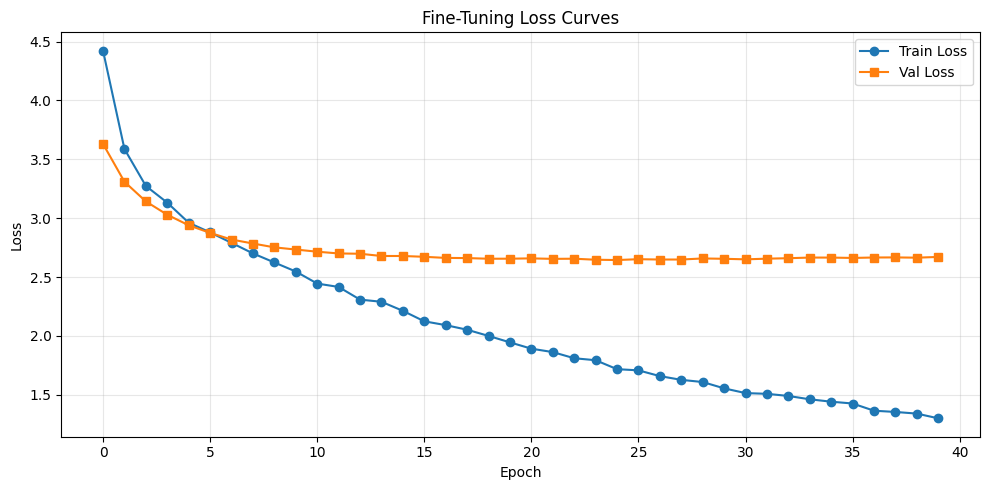

Final train loss: 1.2997
Final val loss: 2.6709


In [19]:
# Plot losses
plt.figure(figsize=(10, 5))
plt.plot(train_losses, label='Train Loss', marker='o')
plt.plot(val_losses, label='Val Loss', marker='s')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Fine-Tuning Loss Curves')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Final train loss: {train_losses[-1]:.4f}")
print(f"Final val loss: {val_losses[-1]:.4f}")

## ?? Expected Behavior: Gibberish Outputs

**Why the model produces nonsensical Q&A responses**:

The pre-trained model from notebook 06 uses **character-level tokenization** (vocab_size = 69), not word-level BPE. This means:

| Aspect | Current (Character-level) | Needed (Word-level BPE) |
|--------|---------------------------|-------------------------|
| vocab_size | 69 | ~2000 |
| "Shakespeare" | 11 tokens (one per char) | 1-2 subword tokens |
| Model learns | Character patterns | Word meanings |
| Q&A capability | ? None | ? Possible |

**To fix this**:
1. Implement actual BPE merging in notebook 06's tokenizer
2. Retrain the model from scratch with the new tokenizer
3. Then fine-tune here - the model will understand word-level concepts

This notebook demonstrates the fine-tuning *process*, but meaningful results require the BPE tokenizer upgrade.

## Section 9: Evaluation - Before vs After

Let's test our fine-tuned model with various questions and compare with the base model behavior.

In [20]:
def extract_answer_text(response: str) -> str:
    if 'Answer:' in response:
        return response.split('Answer:')[-1].strip()
    return response.strip()


def build_eval_prompt(question: str) -> str:
    return (
        '[HAMLET_QA]\n'
        'Instruction: Answer the question in one short factual sentence.\n'
        f'Question: {question}\n'
        'Answer:'
    )


def run_eval_prompt(prompt: str, max_len: int | None = None, temperature: float | None = None) -> str:
    if temperature is None:
        temperature = eval_temperature
    if max_len is None:
        max_len = eval_max_len

    response = generate_sample(
        model,
        tokenizer,
        prompt,
        max_len=max_len,
        temperature=temperature,
        device=device,
        max_seq_len=config['max_seq_len'],
        repetition_penalty=1.2,
    )
    return extract_answer_text(response)


print('=' * 80)
print('EVALUATION: Fine-Tuned Model Responses')
print('=' * 80)
print(f'Using evaluation temperature: {eval_temperature}')
print(f'Using evaluation max_len: {eval_max_len}')

print('\n1. Held-out validation examples')
print('-' * 80)
for i, (question, expected_answer) in enumerate(val_qa[:5], 1):
    prompt = build_eval_prompt(question)
    predicted_answer = run_eval_prompt(prompt)
    print(f'\n{i}. Question: {question}')
    print(f'Expected: {expected_answer}')
    print(f'Predicted: {predicted_answer}')

print('\n' + '=' * 80)
print('2. General hand-written Hamlet prompts')
print('-' * 80)
manual_questions = [
    'Who is Hamlet?',
    'What is Hamlet about?',
    'Who murdered Hamlet\'s father?',
    'Why does Hamlet delay revenge?',
    'What themes appear in Hamlet?',
]

for i, question in enumerate(manual_questions, 1):
    prompt = build_eval_prompt(question)
    predicted_answer = run_eval_prompt(prompt)
    print(f'\n{i}. Question: {question}')
    print('Answer:')
    print(f'Predicted: {predicted_answer}')


EVALUATION: Fine-Tuned Model Responses
Using evaluation temperature: 0.7
Using evaluation max_len: 50

1. Held-out validation examples
--------------------------------------------------------------------------------

1. Question: What is the symbolic meaning of the poison?
Expected: Poison represents corruption spreading invisibly from a hidden source, mirroring how Claudius's crime poisons all of Denmark.
Predicted: The play within Hamlet ' s corrupts, and self - final duty and later dies.

2. Question: What motivates Laertes throughout Hamlet?
Expected: Laertes is motivated primarily by family loyalty and a fierce sense of personal honor for his father and sister.
Predicted: Laertes is important because he mirrors Hamlet ' s uncle and honest friend him as another son sets him truth.

3. Question: What is Claudius's personality like in Hamlet?
Expected: Claudius is politically skilled, deceptive, and morally corrupt.
Predicted: Hamlet watch, and moral consequences without directly.

4

## Section 10: Key Takeaways

### What We Learned

1. **Same Architecture, Different Capability**
   - The model architecture didn't change
   - Only the training data and objective changed
   - Result: Completely different behavior

2. **Importance of Loss Masking**
   - Training on questions would teach the model to generate questions
   - We only want it to generate answers
   - Loss masking focuses the learning signal

3. **Fine-Tuning vs Pre-Training**
   - **Pre-training**: High LR, many epochs, learn language
   - **Fine-tuning**: Low LR, few epochs, learn task
   - Fine-tuning preserves pre-trained knowledge while adding new capability

4. **Data Quality Matters**
   - 500-1000 high-quality Q&A pairs can be effective
   - Template-based generation is a practical approach
   - Better data > more data (to a point)

### Limitations

1. **Limited Knowledge**: The model only knows what's in our Q&A dataset
2. **No Reasoning**: It memorizes answer patterns, doesn't truly understand
3. **Hallucination**: May generate plausible-sounding but incorrect answers
4. **Small Scale**: Real models use millions of Q&A pairs

### Next Steps

To improve this further:

1. **Larger Dataset**: Collect more diverse Q&A pairs
2. **Better Pre-training**: Start with a better base model
3. **RLHF**: Use human feedback to align responses
4. **Prompt Engineering**: Better question formatting

### The Complete LLM Training Pipeline

You now understand the full pipeline:

```
Raw Text ? Tokenization ? Pre-training ? Fine-tuning ? Aligned Model
(NB 05)     (NB 05)        (NB 06)       (NB 07)       (Future: RLHF)
```

This is essentially how GPT-4, Claude, and other modern LLMs are built!

## Summary

In this notebook, we:

1. ? Created a Shakespeare Q&A dataset from scratch
2. ? Implemented the InstructionDataset class with loss masking
3. ? Implemented masked cross-entropy loss
4. ? Fine-tuned our pre-trained model on Q&A pairs
5. ? Evaluated the model's new instruction-following capability

**Key Insight**: Instruction fine-tuning transforms a base language model into an assistant that can follow instructions and answer questions. This is the crucial step that makes models like GPT-4 and Claude useful for real-world applications.

The model now understands the pattern:
```
Question: [user input]
Answer: [helpful response]
```

And can generate appropriate responses to new questions!

---

**Congratulations!** You've now built and trained a complete instruction-following language model from scratch. ??